# Домашнее задание 5.  Обеспечение воспроизводимости эксперимента

In [ ]:
# %%capture
# %pip install feast psycopg psycopg_pool pandas scikit-learn -qqq
# %pip install gdown tqdm -qqq
# %pip install marimo -qqq

In [1]:
from tqdm import tqdm

# import psycopg
import pandas as pd
import warnings

import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import os
import mlflow
import mlflow.sklearn  # < - умеет работать с sklearn
from mlflow.models import infer_signature  # < - умеет вычитывать сигнатуру функции

from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from IPython.display import Image, display
from google.colab import userdata

import gdown
from IPython.display import Video, Image

warnings.filterwarnings("ignore", category=DeprecationWarning)
# !apt-get update -qq > /dev/null
# !apt-get install -y yamllint > /dev/null

/Users/l.tereshchenkova/.pyenv/versions/3.12.12/lib/python3.12/site-packages/google/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# import os
# os.environ["tunatoken"] = userdata.get('tuna')
# !curl -sSLf https://get.tuna.am | sh >/dev/null
# !tuna config save-token $tunatoken

## 1. Выяснить ограничения традиционных ноутбуков Collab при разработке ML-систем по сравнению с [Marimo](https://github.com/marimo-team/marimo)


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=zIad_EXtUcVa)*



In [2]:
!marimo tutorial --help

Usage: marimo tutorial [OPTIONS] {intro|dataflow|ui|markdown|plot
                       s|sql|layout|fileformat|markdown-format|for-jupyter-
                       users}

  Open a tutorial.

  marimo is a powerful library for making reactive notebooks and apps. To get
  the most out of marimo, get started with a few tutorials, starting with the
  intro:

          marimo tutorial intro

  Recommended sequence:

          - intro
          - dataflow
          - ui
          - markdown
          - plots
          - sql
          - layout
          - fileformat
          - markdown-format
          - for-jupyter-users

Options:
  -p, --port INTEGER              Port to attach to.
  --host TEXT                     Host to attach to.  [default: 127.0.0.1]
  --proxy TEXT                    Address of reverse proxy.
  --headless                      Don't launch a browser.
  --token / --no-token            Use a token for authentication. This enables
                                  sessi

In [3]:
print(
    f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте ?access_token=password, нажмите Enter"
)
!sleep 5 && marimo tutorial ui --port 8010 --host 0.0.0.0 --headless --token-password password & tuna http 8010 & wait

Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте ?access_token=password, нажмите Enter
zsh:1: command not found: tuna

        Edit ui.py in your browser 📝

        ➜  URL: http://0.0.0.0:8010?access_token=password
        ➜  Network: http://192.168.1.69:8010?access_token=password

        💡 Tip: Install shell completions
                $ marimo shell-completion



OSError: [Errno 5] Input/output error

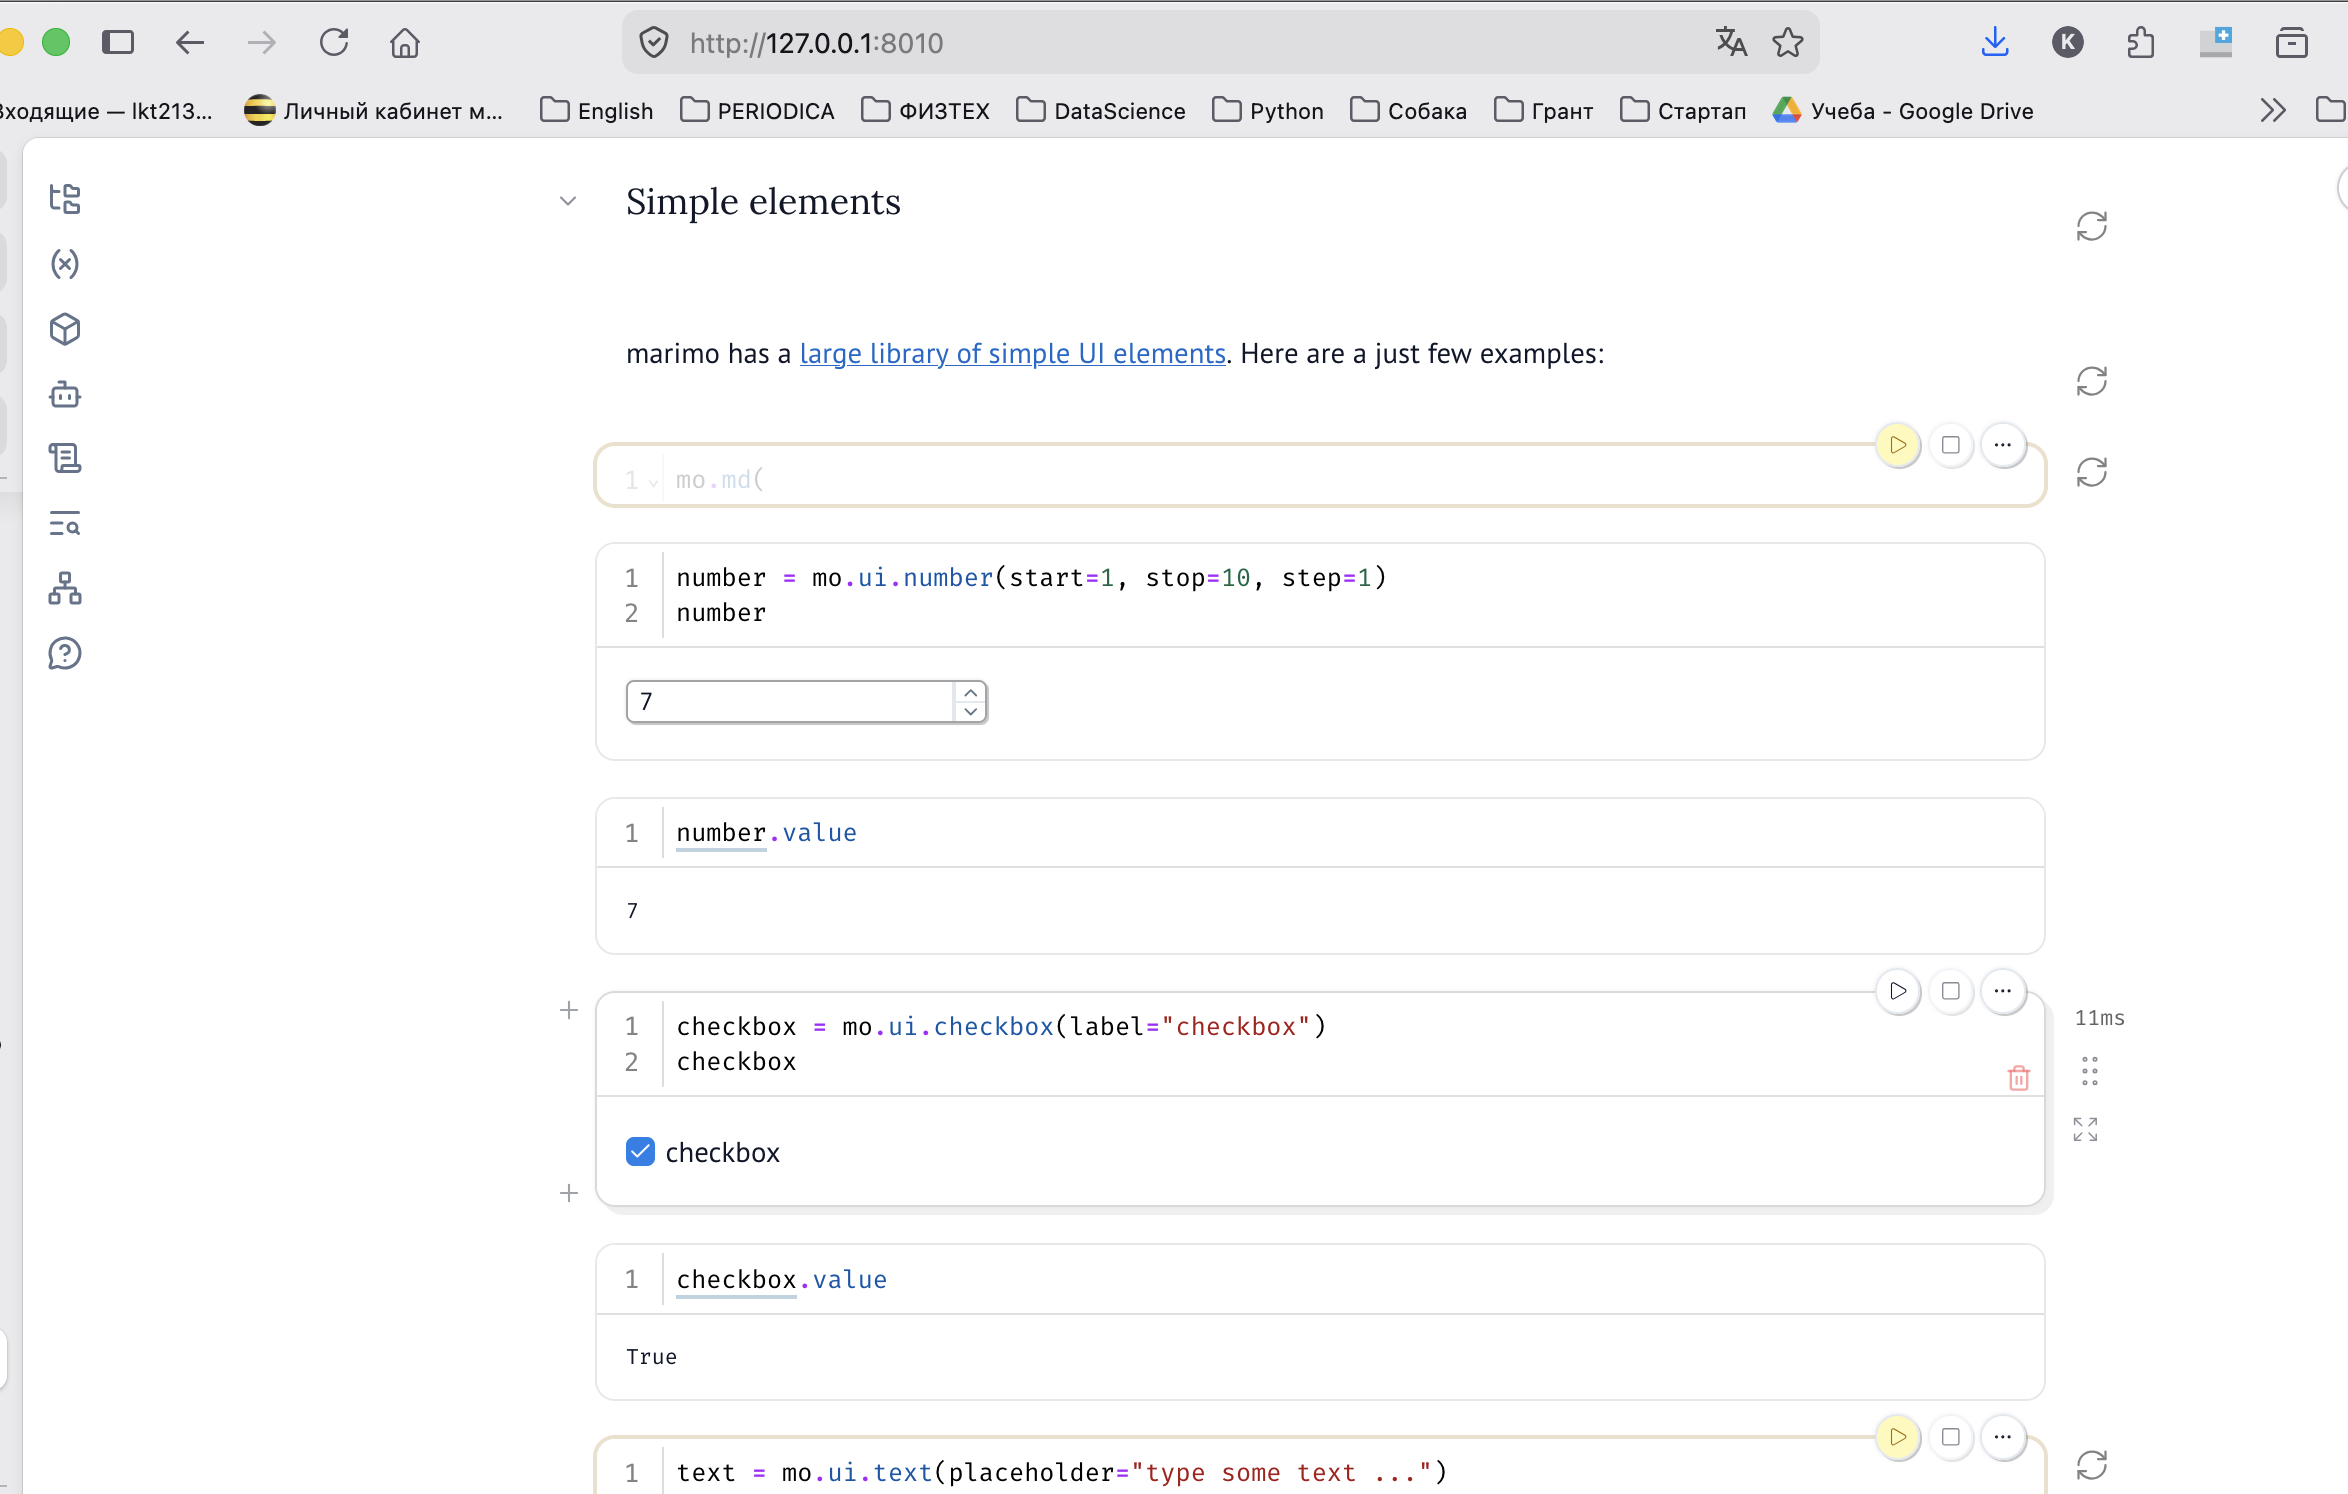

Ваши выводы об удобстве работы с Marimo

- Реактивность “из коробки”: при изменении кода зависимые ячейки пересчитываются автоматически, поэтому меньше ошибок из-за “сломанного” порядка запуска.
- Лучшая воспроизводимость экспериментов: marimo акцентирован на reproducible workflows, а не на “ручной” интерактивной сессии.
- Хранение в виде чистого Python: ноутбук в Marimo — это .py, а не JSON, поэтому удобнее ревьюить, мерджить и версионировать в Git.
- можно делать анализ/запросы и сразу публиковать интерактивный результат, не собирая отдельный стек инструментов вокруг ноутбука.


## 2. Обеспечить воспроизводимость эксперимента, используя DVC/MLflow

* Инициализируйте Git и DVC.
* Добавьте небольшой датасет (например, Iris, Titanic или Wine).
* **Не храните данные в Git, используйте DVC**.
* Создайте пайплайн DVC минимум в две стадии.


*Ожидаемый артефакт: bash-скрипт в [ячейке](#scrollTo=HhN_l9aNrTaV)*



In [4]:
df = pd.read_csv(
    "https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv"
)
df.dropna(inplace=True)
df.to_csv("energydata_complete_v1.csv")

In [5]:
%%bash
# git init && git checkout -b main
# git config --global user.email "publicemail@example.com" && git config --global user.name "publicname"
dvc config core.analytics false
dvc init -f
git add .dvc .dvcignore
dvc remote add -d myremote datasets -f
dvc add energydata_complete_v1.csv && dvc commit
git add energydata_complete_v1.csv.dvc .dvc/config && git commit -m "initial_data"
dvc push
dvc exp remove -A
dvc queue remove --all
touch dvc.yaml
git checkout -b dvc-241106
dvc exp save --name first -m "241106"
dvc exp show
dvc stage add --name=preprocessing --force python script1.py
dvc stage add --name=postprocessing --force python script1.py

Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>
Setting 'myremote' as a default remote.

To track the changes with git, run:

	git add energydata_complete_v1.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true
On branch dvc-241106
Changes not staged for commit:
  (use 

fatal: a branch named 'dvc-241106' already exists
	docker-compose.png, docker-compose-dev.yaml, dvc.yaml, .gitignore, HW5_MLOps_Tereshchenkova_Liliia.ipynb, haarcascade_frontalface_default.xml, datasets/files/md5/9d/69e129ab72daf11e3712a9d8895eb5, content/HW5_Woman_Happy.mp4, content/HW5_Woman_Happy_blurred.gif, local_repo/__init__.py, local_repo/README.md, local_repo/.gitignore, local_repo/feature_repo/__init__.py, local_repo/feature_repo/feature_definitions.py, local_repo/feature_repo/test_workflow.py, local_repo/feature_repo/feature_store.yaml, local_repo/feature_repo/data/registry.db, local_repo/feature_repo/data/driver_stats.parquet


In [6]:
%%bash
git status

On branch dvc-241106
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   dvc.yaml

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .dvc/config
	deleted:    content/energydata_complete_v1.csv.dvc

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	HW5_MLOps_Tereshchenkova_Liliia.ipynb
	content/HW5_Woman_Happy.mp4
	content/HW5_Woman_Happy_blurred.gif
	datasets/
	docker-compose-dev.yaml
	docker-compose.png
	dvc.lock
	haarcascade_frontalface_default.xml
	local_repo/



In [23]:
%%bash
# git add --all
# git commit -m "homework 5"
# cd ../
# git push
git remote get-url main

error: No such remote 'main'


CalledProcessError: Command 'b'# git add --all\n# git commit -m "homework 5"\n# cd ../\n# git push\ngit remote get-url main\n'' returned non-zero exit status 2.

In [ ]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = (
    "http://147.45.147.94:9000"  # < - просто складывает на S3
)
os.environ["AWS_ACCESS_KEY_ID"] = "mlflow"  # < - просто складывает на S3
os.environ["AWS_SECRET_ACCESS_KEY"] = "password"  # < - просто складывает на S3
os.environ["MLFLOW_TRACKING_URI"] = "http://147.45.147.94:5000"  # < - и хранит логи

In [ ]:
mlflow.set_tracking_uri(uri="http://147.45.147.94:5000")
mlflow.set_experiment("KPI tracing")
mlflow.autolog()  # < - и хранит логи

In [ ]:
@mlflow.trace(name="отображение трассировки", attributes={"key": "value"})
def demonstrate_trace(inp=1):
    return 1


with mlflow.start_run(run_name="mlflow.start_run") as run:
    X, y = make_regression(n_features=4, n_informative=2, random_state=0, shuffle=False)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    params = {"max_depth": 10, "random_state": 42}

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    signature = infer_signature(X_test, y_pred)

    mlflow.log_params(params)  # < - и хранит логи
    mlflow.log_metrics({"mse": mean_squared_error(y_test, y_pred)})  # < - и хранит логи

    feature_cols = [f"f{i}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_cols)
    df["target"] = y
    dataset_source_url = "synthetic://make_regression"

    dataset = mlflow.data.from_pandas(
        df,
        source=dataset_source_url,
        name="artifact_path",  # < - просто складывает на S3
        targets="Appliances",
    )
    mlflow.log_input(dataset, context="training")  # < - просто складывает на S3

    mlflow.sklearn.log_model(
        sk_model=model,
        name="sklearn-model",
        signature=signature,
        # registered_model_name="это название модели",            #< - просто складывает на S3
    )

demonstrate_trace()

Выводы:

## 3. Создать хранилище признаков (Feature Store)

Используйте материалы [семинара](https://colab.research.google.com/drive/1TNd3m8-rPrTx1OjRmCnOxUGFueLbXyfe?usp=sharing), чтобы создать хранилище признаков на основе шаблона ```--template [local или postgres]```

Нужно сконфигурировать хранилище признаков в yaml-файле.

*Ожидаемый артефакт: yaml-файл в [ячейке](#scrollTo=8U4_UBuI52-j)*


In [ ]:
!feast init --help
!feast init local_repo --template local

In [ ]:
# %load ./local_repo/feature_repo/feature_store.yaml
# project: local_repo
# # By default, the registry is a file (but can be turned into a more scalable SQL-backed registry)
# registry: data/registry.db
# # The provider primarily specifies default offline / online stores & storing the registry in a given cloud
# provider: local
# online_store:
# type: sqlite
#     path: data/online_store.db
# entity_key_serialization_version: 3
# # By default, no_auth for authentication and authorization, other possible values kubernetes and oidc. Refer the documentation for more details.
# auth:
# type: no_auth

In [ ]:
%%writefile ./local_repo/feature_repo/feature_store.yaml
---
project: feature_repo
registry: data/registry.db
provider: local

online_store:
  type: sqlite
  path: data/online_store.db

entity_key_serialization_version: 3

auth:
  type: no_auth


In [ ]:
!yamllint ./local_repo/feature_repo/feature_store.yaml

In [ ]:
print(
    f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, нажмите Enter"
)
# !sleep 15 & feast ui --host 0.0.0.0 --port 8889 & tuna http 8889 & wait
!feast -c /Users/l.tereshchenkova/MIPT/semester-2/courses/ml-ops/homeworks/HW_05/local_repo/feature_repo ui --host 0.0.0.0 --port 8889

## 4. Обосновать готовность ML-системы к развертыванию в продуктивном окружении

В этом домашнем задании вы сохраняли разные версии данных, создали хранилище признаков для своей ML-системы.

Насколько ML-система готова к развёртыванию?


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=krw6DKDuXtHR)*





Вывод о готовности ML-системы к развёртыванию при наличии версионирования данных и наличии хранилища признаков

## 5. Разработать схему ML-системы для размытия (заблюривания) лиц на изображениях

**Вводные данные от бизнеса: нужно удалить биометрию клиентов с видео, и пример видеоданных.**

*КоАП РФ Статья 13.11.3 Непринятие организационных и технических мер по обеспечению безопасности биометрических персональных данных <...> - влечет наложение административного штрафа на должностных лиц в размере от трехсот тысяч до пятисот тысяч рублей; на юридических лиц - от одного миллиона до одного миллиона пятисот тысяч рублей.*

Нужно ознакомиться с нижеприведенным кодом, осознать что он синхронный и однопоточный, подумать как можно использовать параллелизм данных, выбрать оптимальную архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

*Ожидаемый артефакт: схематическое описание  ML-системы [ячейке](#scrollTo=gggJafKOYvGx)*

In [ ]:
gdrive_url = (
    "https://drive.google.com/uc?export=download&id=1OjSrdAS4zVfa1u7vtyh48PKEoVW20vPN"
)
gdown.download(gdrive_url, output="./content/HW5_Woman_Happy.mp4", quiet=True)
Video("./content/HW5_Woman_Happy.mp4", embed=True, width=640, height=360)

In [ ]:
gdrive_url = (
    "https://drive.google.com/uc?export=download&id=1UEEF9GIVaO2mRKxVFIaU2Dn1Jjnj7-OU"
)
gdown.download(gdrive_url, quiet=True, output="./content/HW5_Woman_Happy_blurred.gif")
Image("./content/HW5_Woman_Happy_blurred.gif", embed=True, width=640, height=360)

%%html

Нижеприведенный код ML-системы обрабатывает каждый кадр видео так:

<table >
		<tr>
			<td>
      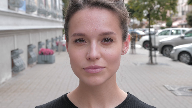
      </td>
      <td>
      <font size="96px">
      &#10145;</font>
      </td>
			<td>
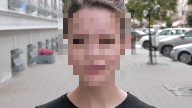
</td>
		</tr>
</table>

In [ ]:
%pip install opencv-python

In [ ]:
!brew install wget

In [ ]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml -O ./haarcascade_frontalface_default.xml


def apply_mosaic_effect(face_roi, pixel_size=10):
    if face_roi.shape[0] == 0 or face_roi.shape[1] == 0:
        return face_roi
    h, w, _ = face_roi.shape
    small_h = max(1, h // pixel_size)
    small_w = max(1, w // pixel_size)
    if small_h == 0:
        small_h = 1
    if small_w == 0:
        small_w = 1
    downscaled = cv2.resize(
        face_roi, (small_w, small_h), interpolation=cv2.INTER_LINEAR
    )
    mosaiced_face = cv2.resize(downscaled, (w, h), interpolation=cv2.INTER_NEAREST)
    return mosaiced_face


output_video_path = "./content/HW5_Woman_Happy_blurred.mp4"
video_file_path = "./content/HW5_Woman_Happy.mp4"
video_capture = cv2.VideoCapture(video_file_path)
face_cascade = cv2.CascadeClassifier("./haarcascade_frontalface_default.xml")

if not video_capture.isOpened():
    print("Error: Could not open video file.")
else:
    fps = int(video_capture.get(cv2.CAP_PROP_FPS))
    width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*"XVID")
    video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(
        f"Загружено видео с характеристиками: FPS={fps}, Width={width}, Height={height}"
    )
    print(f"VideoWriter начинает запись в файл: {output_video_path}")

    video_capture.set(
        cv2.CAP_PROP_POS_FRAMES, 0
    )  # Reset video_capture to the beginning
    with tqdm(total=frame_count, desc="обработано ") as pbar:
        while video_capture.isOpened():
            ret, frame = video_capture.read()
            if not ret:
                break
            pbar.update(1)

            if False:
                cv2_imshow(
                    cv2.resize(
                        frame, None, fx=0.05, fy=0.05, interpolation=cv2.INTER_LINEAR
                    )
                )

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.1, 4)

            for x, y, w, h in faces:
                face_roi = frame[y : y + h, x : x + w]
                mosaiced_face = apply_mosaic_effect(face_roi, pixel_size=100)
                frame[y : y + h, x : x + w] = mosaiced_face
            video_writer.write(frame)

    video_capture.release()
    video_writer.release()
    cv2.destroyAllWindows()

    print(f"\nVideoWriter записал видео в файл {output_video_path}")

диаграмма ML-системы

In [ ]:
%%writefile docker-compose-dev.yaml
---
version: "3.9"

services:
  notebook:
    image: jupyter/base-notebook:python-3.11
    container_name: hw5_notebook
    ports:
      - "8888:8888"
    volumes:
      - ./:/workspace
    environment:
      - MLFLOW_TRACKING_URI=http://mlflow:5000
      - MLFLOW_S3_ENDPOINT_URL=http://minio:9000
      - AWS_ACCESS_KEY_ID=mlflow
      - AWS_SECRET_ACCESS_KEY=password
    depends_on:
      - mlflow
      - minio
      - feast_ui
    labels:
      docker_compose_diagram.icon: "diagrams.onprem.client.Users"
      docker_compose_diagram.cluster: "ML Platform"
      docker_compose_diagram.description: "Notebook / Experiments\n(DVC+MLflow+Feast usage)"

  dvc_pipeline:
    image: python:3.11-slim
    container_name: hw5_dvc_pipeline
    volumes:
      - ./:/workspace
    working_dir: /workspace
    command: ["bash", "-lc", "echo DVC stages: prepare -> train"]
    labels:
      docker_compose_diagram.icon: "diagrams.onprem.workflow.Airflow"
      docker_compose_diagram.cluster: "Data & Training"
      docker_compose_diagram.description: "DVC pipeline\n(stage1 prepare, stage2 train)"

  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.14.1
    container_name: hw5_mlflow
    ports:
      - "5000:5000"
    command: >
      mlflow server
      --host 0.0.0.0
      --port 5000
      --backend-store-uri sqlite:///mlflow.db
      --artifacts-destination s3://mlflow/
    depends_on:
      - minio
    labels:
      docker_compose_diagram.icon: "diagrams.onprem.monitoring.Grafana"
      docker_compose_diagram.cluster: "Experiment Tracking"
      docker_compose_diagram.description: "MLflow Tracking Server"

  minio:
    image: minio/minio:latest
    container_name: hw5_minio
    ports:
      - "9000:9000"
      - "9001:9001"
    command: server /data --console-address ":9001"
    environment:
      - MINIO_ROOT_USER=mlflow
      - MINIO_ROOT_PASSWORD=password
    volumes:
      - minio_data:/data
    labels:
      docker_compose_diagram.icon: "diagrams.onprem.storage.CephOsd"
      docker_compose_diagram.cluster: "Artifacts Storage"
      docker_compose_diagram.description: "S3 artifacts\n(models, logs, datasets)"

  feast_ui:
    image: python:3.11-slim
    container_name: hw5_feast_ui
    ports:
      - "8889:8889"
    volumes:
      - ./local_repo/feature_repo:/feature_repo
    working_dir: /feature_repo
    command: ["bash", "-lc", "echo Feast UI / Feature repo"]
    labels:
      docker_compose_diagram.icon: "diagrams.onprem.analytics.Superset"
      docker_compose_diagram.cluster: "Feature Store"
      docker_compose_diagram.description: "Feast\nregistry.db + online_store.db"

  blur_inference:
    image: python:3.11-slim
    container_name: hw5_blur_inference
    volumes:
      - ./:/workspace
    working_dir: /workspace
    command: ["bash", "-lc", "echo OpenCV face blur inference service"]
    depends_on:
      - feast_ui
      - mlflow
    labels:
      docker_compose_diagram.icon: "diagrams.onprem.compute.Server"
      docker_compose_diagram.cluster: "Inference"
      docker_compose_diagram.description: "OpenCV face blur\nmodel/video processing"

volumes:
  minio_data:

In [ ]:
!yamllint ./docker-compose-dev.yaml

In [ ]:
!compose-diagram --file docker-compose-dev.yaml

In [ ]:
image_path = "./docker-compose.png"
display(Image(filename=image_path))

## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали о воспроизводимости эксперимента c DVC/MLflow в реальных проектах.

